In [10]:
import jax
import jax.numpy as jnp
from jax.experimental import pallas as pl

# The kernel: it will receive sub-arrays (tiles) corresponding to blocks of x, y, and z.
def matmul_kernel(x_ref, y_ref, z_ref):
    # Each kernel computes one output tile as the product of its x_ref and y_ref.
    start_x = pl.program_id(0)
    start_y = pl.program_id(1)
    
    z_ref[...] = x_ref[...] @ y_ref[...]

def matmul(x: jax.Array, y: jax.Array, grid=(2, 2)) -> jax.Array:
    """
    Computes the matrix product of x and y using a tiled (block) kernel.
    
    Args:
        x: A (M x K) array.
        y: A (K x N) array.
        grid: A tuple (grid_rows, grid_cols) specifying the tiling.
              x is partitioned into grid_rows blocks by rows,
              y is partitioned into grid_cols blocks by columns.
              
    Returns:
        A (M x N) array equal to x @ y.
    
    Note: Assumes that M and N are divisible by grid_rows and grid_cols respectively.
    """
    M, K = x.shape
    K2, N = y.shape
    if K != K2:
        raise ValueError("Inner dimensions must agree: x.shape[1] == y.shape[0].")
    
    grid_rows, grid_cols = grid
    if M % grid_rows != 0:
        raise ValueError("Number of rows of x must be divisible by grid_rows.")
    if N % grid_cols != 0:
        raise ValueError("Number of columns of y must be divisible by grid_cols.")
    
    # Define the block shapes and starting-index lambdas.
    # For x: we partition by rows; each block is (M//grid_rows, K) and starts at row i*(M//grid_rows)
    x_block_spec = pl.BlockSpec(
        block_shape=(M // grid_rows, K),
        index_map=lambda i, j: (i * (M // grid_rows), 0)
    )
    
    # For y: we partition by columns; each block is (K, N//grid_cols) and starts at column j*(N//grid_cols)
    y_block_spec = pl.BlockSpec(
        block_shape=(K, N // grid_cols),
        index_map=lambda i, j: (0, j * (N // grid_cols))
    )
    
    # For the output: each block is (M//grid_rows, N//grid_cols) and its offset is (i*(M//grid_rows), j*(N//grid_cols))
    z_block_spec = pl.BlockSpec(
        block_shape=(M // grid_rows, N // grid_cols),
        index_map=lambda i, j: (i * (M // grid_rows), j * (N // grid_cols))
    )
    
    # Use pallas_call to compile and run the kernel over the grid.
    return pl.pallas_call(
        matmul_kernel,
        out_shape=jax.ShapeDtypeStruct((M, N), x.dtype),
        grid=grid,
        in_specs=[x_block_spec, y_block_spec],
        out_specs=z_block_spec
    )(x, y)

# Example usage:
if __name__ == '__main__':
    key = jax.random.PRNGKey(0)
    M, K, N = 32, 32, 32
    # Make sure M and N are divisible by grid dimensions (here, 2).
    A = jax.random.normal(key, (M, K))
    B = jax.random.normal(key, (K, N))
    
    # Compute matrix multiplication with a 2x2 tiling.
    C = matmul(A, B, grid=(2, 2))
    # Verify against JAX’s matmul.
    assert jnp.allclose(C, A @ B)
    print("matmul succeeded, result:\n", C)


AssertionError: 

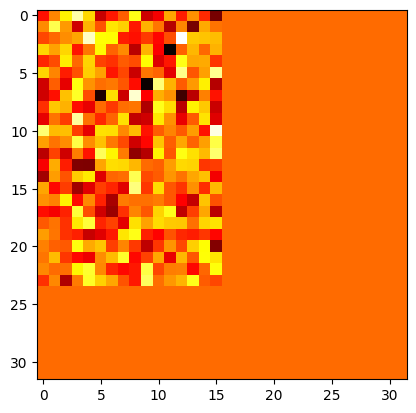

In [14]:
import matplotlib.pyplot as plt
plt.imshow(C, cmap='hot', interpolation='nearest')